In [1]:
! pip install matplotlib
! pip install pandas
! pip install scikit-learn
! pip install scikit-image

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Q1: Please perform K-Means with k=3, 5, 7, 9 for the spectral data as shown below (see ”example_spec.csv”) and plot the results.

In [3]:
### load data
data = pd.read_csv('example_spec.csv', header=None)
data

,0,1,2,3,4,5,6,7,8,9,...,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375
0,400.000000,402.000000,404.000000,406.000000,408.000000,410.000000,412.000000,414.000000,416.000000,418.000000,...,3132.000000,3134.000000,3136.000000,3138.000000,3140.000000,3142.000000,3144.000000,3146.000000,3148.000000,3150.000000
1,80.409758,82.525749,70.133355,66.762569,76.588555,81.967791,79.486085,71.199797,62.355309,58.735971,...,8.660097,5.175334,8.597552,10.262741,9.982491,10.334204,9.371966,16.830934,24.366608,19.967173
2,77.216561,62.376232,58.634579,67.512361,80.244789,79.185585,66.275337,49.969002,36.839971,30.930802,...,16.492064,5.287952,8.031540,6.872706,9.833553,14.837850,-2.955869,-1.679584,12.059411,20.143331
3,74.633856,79.575896,72.125330,60.096492,50.503123,47.322154,49.015793,51.900495,49.847033,38.682827,...,7.359474,-12.905309,6.838368,17.632250,5.059827,7.640288,4.726514,5.324807,16.674430,29.341040
4,77.498622,71.306948,85.262589,83.609745,66.975961,70.062134,69.470127,36.657058,9.672315,30.919074,...,24.755072,0.878504,-3.171191,12.539897,30.154807,30.821919,10.936996,7.905039,13.209277,11.792370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,133.121700,125.423989,134.936621,137.801126,120.817304,90.347437,77.913085,109.294777,145.325251,140.940285,...,1.810858,-2.445955,2.254883,0.689670,-2.996327,6.643203,20.930579,6.374586,-9.671725,-10.236983
97,89.387293,79.080027,61.056192,51.778569,53.349280,50.540696,39.153420,20.822223,6.335359,6.566209,...,17.724735,14.791020,13.692711,6.451921,3.124320,10.047654,14.466106,13.862040,5.935683,2.091197
98,62.912643,55.230136,47.776575,58.476725,79.586173,77.035613,58.505852,44.106047,41.144327,49.485840,...,20.368072,30.955161,18.905626,7.022299,5.282636,10.749624,20.061126,12.168057,11.047212,14.458266
99,43.884806,45.646617,52.440729,47.428118,34.066524,28.316856,27.991125,28.031418,27.240930,25.572357,...,14.049790,10.690016,7.529614,9.896679,10.055967,6.276745,12.762249,11.094414,7.370803,7.726233


/tmp/ipykernel_692/1759650028.py:5: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  spec = np.row_stack([row/np.sqrt(np.sum(row**2)) for i, row in spec.iterrows()])


Text(0, 0.5, 'Intensity / arb. u.')

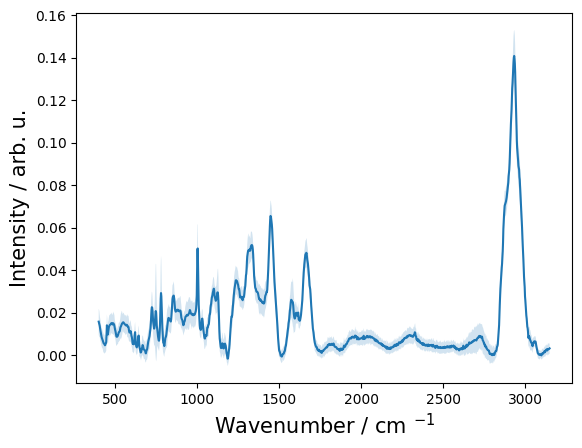

In [4]:
### plot data
wn = data.iloc[0, :]
spec = data.iloc[1:, :]

spec = np.row_stack([row/np.sqrt(np.sum(row**2)) for i, row in spec.iterrows()])


spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean)
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)

In [5]:
### perform k-Means
from sklearn.cluster import KMeans

n_cluster = 3  ## k = 3
kmeans_spec = KMeans(n_clusters=n_cluster, random_state=0).fit(spec)
cluster_spec = kmeans_spec.labels_
cluster_spec

array([1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2,
       1, 1, 2, 1, 1, 1, 0, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2,
       2, 0, 1, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2,
       2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 1, 0, 1, 1, 1, 2, 1,
       2, 2, 1, 0, 1, 2, 2, 1, 2, 2, 2, 1], dtype=int32)

In [6]:
### get cluster centers
center_spec = kmeans_spec.cluster_centers_
center_spec.shape

(3, 1376)

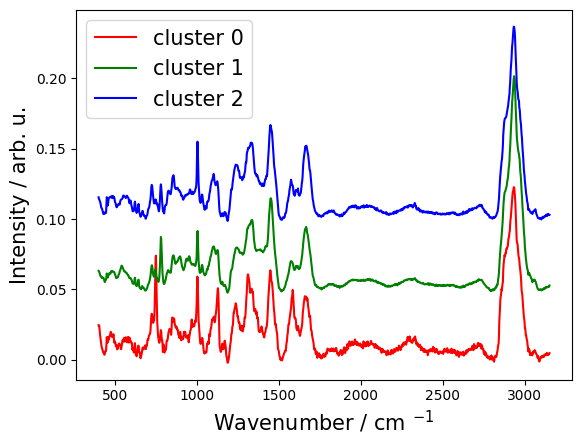

In [7]:
### plot cluster centers
colors = ['red', 'green', 'blue']
gap = 0.05
for i in range(n_cluster):
    plt.plot(wn, center_spec[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)   
plt.legend(fontsize=15)

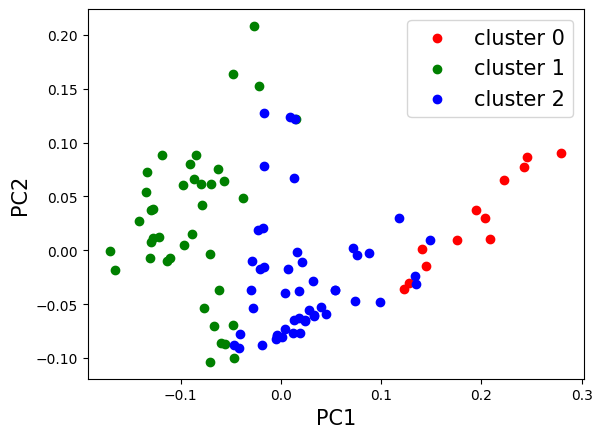

In [8]:
### plot PCA with cluster information
scores_spec = PCA(n_components=2).fit_transform(spec)
for i in range(n_cluster):
    plt.scatter(scores_spec[cluster_spec==i, 0], scores_spec[cluster_spec==i, 1], color=colors[i], label='cluster '+str(i))
plt.xlabel("PC1", fontsize=15)
plt.ylabel('PC2', fontsize=15)   
plt.legend(fontsize=15)

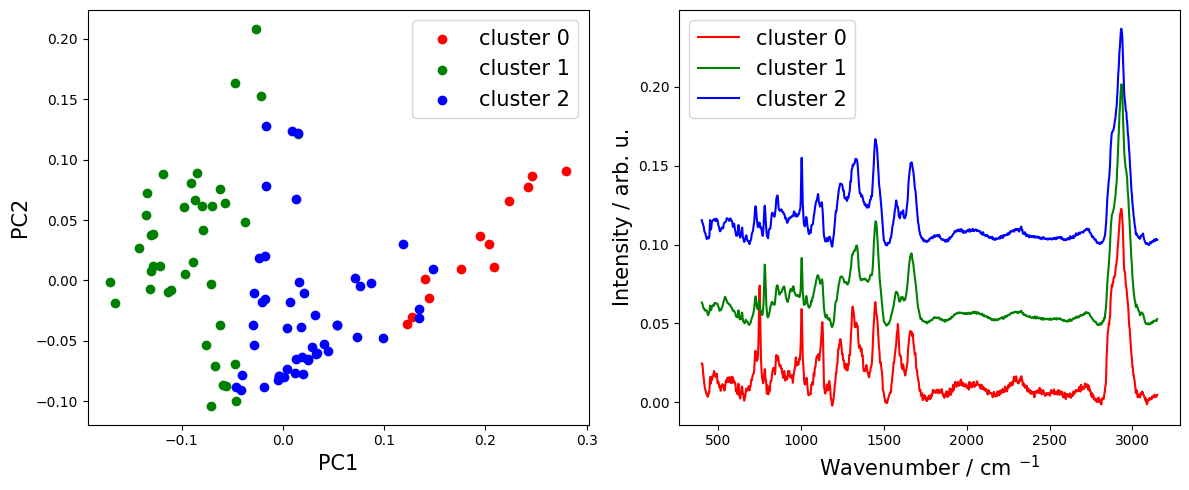

In [9]:
### plot everything in one figure
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

### plot scores at left side
for i in range(n_cluster):
    ax[0].scatter(scores_spec[cluster_spec==i, 0], scores_spec[cluster_spec==i, 1], color=colors[i], label='cluster '+str(i))
ax[0].set_xlabel("PC1", fontsize=15)
ax[0].set_ylabel('PC2', fontsize=15)   
ax[0].legend(fontsize=15)

### plot centers at left side
gap = 0.05
for i in range(n_cluster):
    ax[1].plot(wn, center_spec[i, :] + i*gap, color=colors[i], label='cluster '+str(i))
ax[1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
ax[1].set_ylabel('Intensity / arb. u.', fontsize=15)   
ax[1].legend(fontsize=15)

plt.tight_layout()

# Q2: Please perform K-Means with k=3, 5, 7, 9 for the image data ”example_image.png” (see plot below) and plot the results.

(np.float64(-0.5), np.float64(1349.5), np.float64(1484.5), np.float64(-0.5))

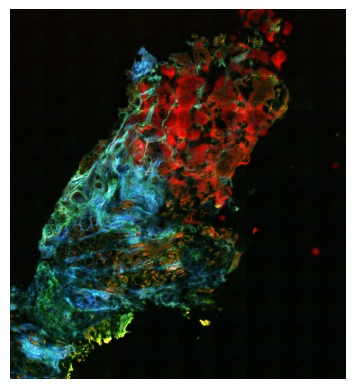

In [10]:
### read and display the image 
import skimage as ski
image = ski.io.imread('example_image.png')
plt.imshow(image)
plt.axis('off')

In [11]:
im_shape = image.shape
im_shape

(1485, 1350, 3)

In [12]:
### clustering

### first unfold image into rows*features 
image_2d = image.reshape((im_shape[0]*im_shape[1], 3))

### do k-means
n_cluster = 3  ## k = 3
kmeans_im = KMeans(n_clusters=n_cluster, random_state=0).fit(image_2d)
cluster_im = kmeans_im.labels_
cluster_im.shape

(2004750,)

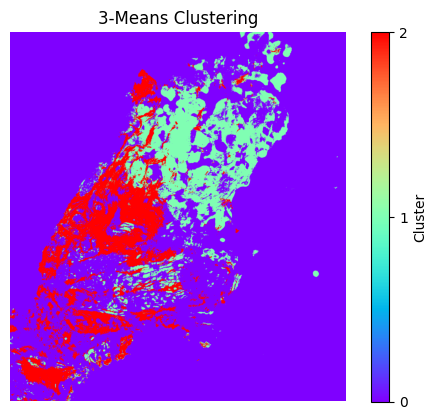

In [13]:
### fold cluster results back into image and display the results
cluster_im2D = cluster_im.reshape( (im_shape[0], im_shape[1]) )
r_cluster = plt.imshow(cluster_im2D, cmap='rainbow')
plt.axis('off')
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster))
cbar.set_label("Cluster")
plt.title(str(n_cluster)+ '-Means Clustering')
plt.show()

/tmp/ipykernel_692/458029830.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


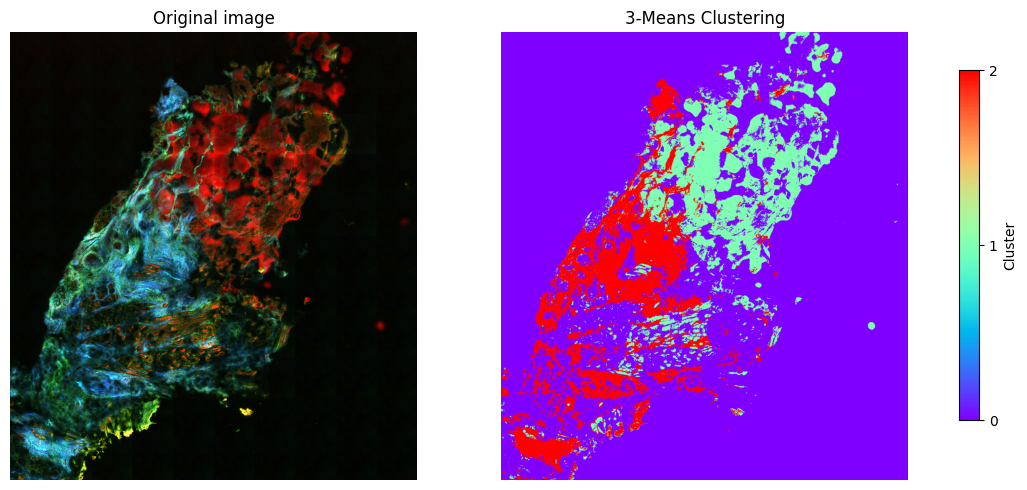

In [14]:
### plot everything in one figure
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].axis('off')
ax[0].set_title('Original image')

r_cluster = ax[1].imshow(cluster_im2D, cmap='rainbow')
ax[1].axis('off')
ax[1].set_title(str(n_cluster)+ '-Means Clustering')

cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = plt.colorbar(r_cluster, ticks=np.arange(n_cluster), shrink=0.75, cax=cbar_ax)
cbar.set_label("Cluster")

plt.tight_layout()
plt.show()